In [2]:
# Cell 1 - install packages
# run this first, then restart runtime before continuing

!pip uninstall -y Pillow facenet-pytorch 2>/dev/null
!pip install -q Pillow==10.4.0 --no-deps
!pip install -q gdown==4.7.3 mtcnn scikit-learn tqdm
!pip install -q "albumentations>=1.4.0"
!pip install -q torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q timm   # for EfficientNet / ViT

print("✅ Done. RESTART RUNTIME NOW, then continue from Cell 2.")


Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 93.5 MB/s eta 0:00:00
✅ Done. RESTART RUNTIME NOW, then continue from Cell 2.


In [3]:
# Cell 2 - imports
import os, random, warnings, subprocess, zipfile
import numpy as np
import scipy.fft as sfft

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, ConcatDataset, TensorDataset

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import timm

from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import albumentations as A
from albumentations.pytorch import ToTensorV2
from mtcnn import MTCNN

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device     : {device}")
print(f"✅ PIL        : {Image.__version__}")
print(f"✅ PyTorch    : {torch.__version__}")
print(f"✅ CUDA avail : {torch.cuda.is_available()}")
print(f"✅ timm       : {timm.__version__}")


✅ Device     : cuda
✅ PIL        : 11.3.0
✅ PyTorch    : 2.10.0+cu128
✅ CUDA avail : True
✅ timm       : 1.0.26


In [4]:
# Cell 3 - download MSCTD En-De dataset (labels + images)
BASE_DIR    = "/content/msctd/data/ende"
GITHUB_BASE = "https://github.com/XL2248/MSCTD/raw/main/MSCTD_data/ende"
os.makedirs(BASE_DIR, exist_ok=True)

# grab label files for each split
print("Downloading label files...")
for split in ["train", "dev", "test"]:
    for fname in [f"sentiment_{split}.txt", f"english_{split}.txt"]:
        out = os.path.join(BASE_DIR, fname)
        if not os.path.exists(out):
            r = subprocess.run(["wget", "-q", f"{GITHUB_BASE}/{fname}", "-O", out],
                               capture_output=True, text=True)
            print(f"  {'✅' if r.returncode==0 else '❌'} {fname}")
        else:
            print(f"  ⏭  {fname}")

# helper functions for zip handling and image flattening
def is_valid_zip(p):
    try:
        with zipfile.ZipFile(p, 'r') as z:
            return len(z.namelist()) > 0
    except Exception:
        return False

def flatten_jpgs(folder):
    import shutil
    moved = 0
    for root, dirs, files in os.walk(folder):
        if root == folder: continue
        for fn in files:
            if fn.lower().endswith('.jpg'):
                src = os.path.join(root, fn)
                dst = os.path.join(folder, fn)
                if not os.path.exists(dst):
                    shutil.move(src, dst)
                    moved += 1
    return moved

def count_jpgs(folder):
    n = 0
    for root, _, files in os.walk(folder):
        n += sum(1 for f in files if f.lower().endswith('.jpg'))
    return n

def try_download(gid, zip_path):
    url = f"https://drive.google.com/uc?id={gid}"
    for cmd in [
        ["gdown", "--fuzzy", url, "-O", zip_path],
        ["gdown", url, "-O", zip_path],
        ["wget", "-q", "--no-check-certificate",
         f"https://drive.google.com/uc?export=download&confirm=t&id={gid}",
         "-O", zip_path],
    ]:
        subprocess.run(cmd, capture_output=True, text=True)
        if is_valid_zip(zip_path):
            return True
        if os.path.exists(zip_path):
            os.remove(zip_path)
    return False

# multiple IDs per split as fallback in case one Drive link goes down
IMAGE_IDS = {
    "train": ["1GAZgPpTUBSfhne-Tp0GDkvSHuq6EMMbj", "1-1NCqtM8rb8qpjSTE250j6b7ELPeUWSP"],
    "dev":   ["1B9ZSxBCKkT70_Wdj6lMmMSsHVBgz2sL5", "1MQVgE3zOqaia3XAUuxlqsOs8QHGJoQGL"],
    "test":  ["11c8PpV9kECkl-x7xIEmuzEjyYHyoACgh",  "1rJBfKDkF4DVaqJGa5JUm9XJEGFEmpSM9"],
}

print("\nDownloading image archives...")
for split, gid_list in IMAGE_IDS.items():
    img_dir  = os.path.join(BASE_DIR, split)
    zip_path = os.path.join(BASE_DIR, f"{split}_images.zip")
    os.makedirs(img_dir, exist_ok=True)

    existing = count_jpgs(img_dir)
    if existing > 0:
        moved = flatten_jpgs(img_dir)
        final = sum(1 for f in os.listdir(img_dir) if f.lower().endswith('.jpg'))
        print(f"  ⏭  {split}: {final} images ready"
              + (f" ({moved} moved to root)" if moved else ""))
        continue

    if os.path.exists(zip_path) and not is_valid_zip(zip_path):
        print(f"  🗑  Removing corrupt {split}_images.zip")
        os.remove(zip_path)

    success = False
    if not os.path.exists(zip_path):
        print(f"  Downloading {split} (trying {len(gid_list)} source(s))...")
        for gid in gid_list:
            print(f"    ID {gid[:24]}...", end=" ", flush=True)
            if try_download(gid, zip_path):
                print("✅"); success = True; break
            print("❌")
    else:
        success = True

    if not success:
        print(f"  ❌ All sources failed for {split} → run Cell 3b.")
        continue

    subprocess.run(["unzip", "-q", "-o", zip_path, "-d", img_dir], capture_output=True)
    moved = flatten_jpgs(img_dir)
    n = sum(1 for f in os.listdir(img_dir) if f.lower().endswith('.jpg'))
    print(f"  {'✅' if n>0 else '❌'} {split}: {n} images"
          + (f" ({moved} moved from subfolders)" if moved else ""))

print("\n✅ MSCTD En-De Ready!")
print("   Any split still at 0 images → run Cell 3b below.")


  ✅ sentiment_train.txt
  ✅ english_train.txt
  ✅ sentiment_dev.txt
  ✅ english_dev.txt
  ✅ sentiment_test.txt
  ✅ english_test.txt

    ID 1GAZgPpTUBSfhne-Tp0GDkvS... ✅
  ✅ train: 20240 images (20240 moved from subfolders)
    ID 1B9ZSxBCKkT70_Wdj6lMmMSs... ❌
    ID 1MQVgE3zOqaia3XAUuxlqsOs... ✅
  ✅ dev: 5063 images (5063 moved from subfolders)
    ID 11c8PpV9kECkl-x7xIEmuzEj... ✅
  ✅ test: 5067 images (5067 moved from subfolders)

✅ MSCTD En-De Ready!
   Any split still at 0 images → run Cell 3b below.


In [5]:
# Cell 3b - manual fallback if Cell 3 download failed
# 1. Download zips manually and upload to Colab via the Files panel
#      Train: https://drive.google.com/uc?id=1GAZgPpTUBSfhne-Tp0GDkvSHuq6EMMbj
#      Dev:   https://drive.google.com/uc?id=1B9ZSxBCKkT70_Wdj6lMmMSsHVBgz2sL5
#      Test:  https://drive.google.com/file/d/11c8PpV9kECkl-x7xIEmuzEjyYHyoACgh
# 2. Run this cell

import zipfile, os, shutil
BASE_DIR = "/content/msctd/data/ende"

UPLOADED_ZIPS = {
    "train": "/content/train_images.zip",
    "dev":   "/content/dev_images.zip",
    "test":  "/content/test_images.zip",
}

def flatten_jpgs(folder):
    moved = 0
    for root, dirs, files in os.walk(folder):
        if root == folder: continue
        for fn in files:
            if fn.lower().endswith('.jpg'):
                src = os.path.join(root, fn)
                dst = os.path.join(folder, fn)
                if not os.path.exists(dst):
                    shutil.move(src, dst)
                    moved += 1
    return moved

for split, zip_path in UPLOADED_ZIPS.items():
    out_dir = f"{BASE_DIR}/{split}"
    if not os.path.exists(zip_path):
        print(f"⏭  {zip_path} not found — skipping {split}")
        continue
    os.makedirs(out_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    moved = flatten_jpgs(out_dir)
    n = sum(1 for f in os.listdir(out_dir) if f.lower().endswith(".jpg"))
    print(f"✅ {split}: {n} images"
          + (f" ({moved} moved from subfolders)" if moved else ""))


⏭  /content/train_images.zip not found — skipping train
⏭  /content/dev_images.zip not found — skipping dev
⏭  /content/test_images.zip not found — skipping test


In [6]:
# Cell 4 - dataset class
LABEL_NAMES = ['Neutral', 'Negative', 'Positive']
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

class MSCTDDataset(Dataset):
    """loads images + labels, sorts by filename so indices match up"""
    def __init__(self, image_dir, sentiment_path, transform=None):
        self.transform = transform
        with open(sentiment_path) as f:
            self.labels = [int(x.strip()) for x in f if x.strip()]
        self.image_files = []
        for root, _, files in os.walk(image_dir):
            for fn in files:
                if fn.lower().endswith('.jpg'):
                    self.image_files.append(os.path.join(root, fn))
        self.image_files = sorted(
            self.image_files,
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
        self.length = min(len(self.labels), len(self.image_files))
        print(f"  ✅ {image_dir.split('/')[-1]:6s}: {self.length} samples "
              f"(labels={len(self.labels)}, images={len(self.image_files)})")

    def __len__(self): return self.length

    def __getitem__(self, idx):
        try:
            img = Image.open(self.image_files[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (128, 128, 128))
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


In [7]:
import shutil

# augmentation for training — heavier transforms to improve generalisation
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    T.RandomGrayscale(p=0.1),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])
# test/val just resize + normalise, no augmentation
test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

BASE_DIR = "/content/msctd/data/ende"

def flatten_and_count(folder):
    """move all jpgs from subfolders into root, return count"""
    for root, dirs, files in os.walk(folder):
        if root == folder: continue
        for fn in files:
            if fn.lower().endswith('.jpg'):
                src = os.path.join(root, fn)
                dst = os.path.join(folder, fn)
                if not os.path.exists(dst):
                    shutil.move(src, dst)
    return sum(1 for f in os.listdir(folder) if f.lower().endswith('.jpg'))

print("Checking image directories...")
for split in ["train", "dev", "test"]:
    d = f"{BASE_DIR}/{split}"
    os.makedirs(d, exist_ok=True)
    n = flatten_and_count(d)
    print(f"  {split}: {n} images")

print("\nLoading splits...")
train_ds = MSCTDDataset(f"{BASE_DIR}/train", f"{BASE_DIR}/sentiment_train.txt", train_transform)
dev_ds   = MSCTDDataset(f"{BASE_DIR}/dev",   f"{BASE_DIR}/sentiment_dev.txt",   test_transform)
test_ds  = MSCTDDataset(f"{BASE_DIR}/test",  f"{BASE_DIR}/sentiment_test.txt",  test_transform)

missing = [s for ds, s in [(train_ds,"train"),(dev_ds,"dev"),(test_ds,"test")] if len(ds)==0]
if missing:
    print(f"\n❌ Empty splits: {missing}")
    print("   A) Re-run Cell 3 to retry auto-download")
    print("   B) Download zip manually, upload to Colab, run Cell 3b")
    raise RuntimeError(f"Dataset empty for: {missing}")

# compute inverse-frequency class weights to handle class imbalance
label_counts  = torch.tensor([train_ds.labels.count(i) for i in range(3)], dtype=torch.float)
raw_weights   = label_counts.sum() / (3 * label_counts)
class_weights = (raw_weights / raw_weights.max()).to(device)
print(f"\nClass counts  : Neutral={int(label_counts[0])}, "
      f"Negative={int(label_counts[1])}, Positive={int(label_counts[2])}")
print(f"Class weights : {class_weights.cpu().numpy().round(3)}")

BATCH = 32
NUM_WORKERS = 8
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
print(f"\nTrain={len(train_ds)} | Dev={len(dev_ds)} | Test={len(test_ds)}")
print("✅ Splits and loaders ready.")

Checking image directories...
  train: 20240 images
  dev: 5063 images
  test: 5067 images

Loading splits...
  ✅ train : 20240 samples (labels=20240, images=20240)
  ✅ dev   : 5063 samples (labels=5063, images=5063)
  ✅ test  : 5067 samples (labels=5067, images=5067)

Class counts  : Neutral=6922, Negative=7835, Positive=5483
Class weights : [0.792 0.7   1.   ]

Train=20240 | Dev=5063 | Test=5067
✅ Splits and loaders ready.


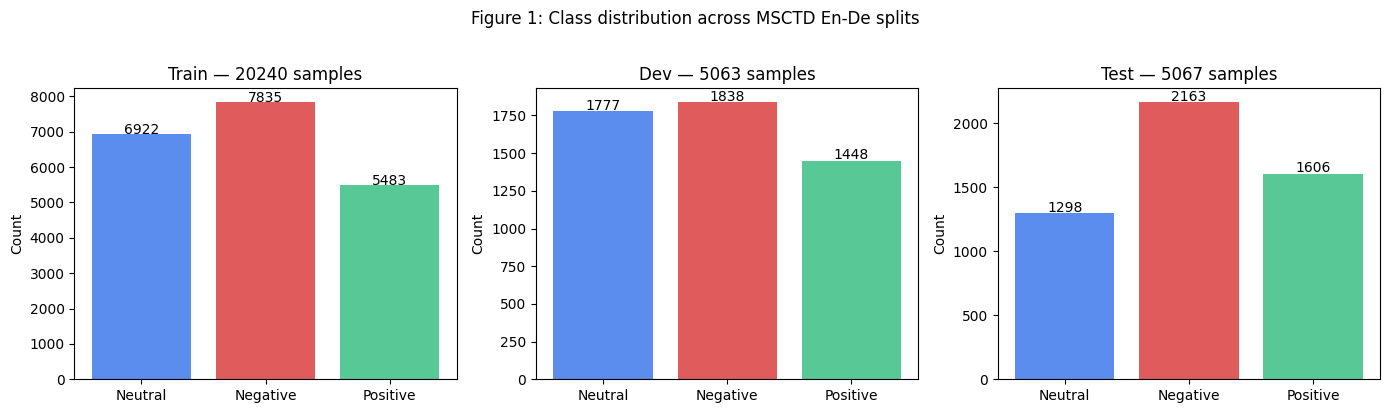

In [8]:
# Cell 6 - plot class distribution across splits (Figure 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#5b8dee', '#e05c5c', '#58c896']
for ax, ds, title in zip(axes, [train_ds, dev_ds, test_ds], ["Train", "Dev", "Test"]):
    counts = [ds.labels.count(i) for i in range(3)]
    bars = ax.bar(LABEL_NAMES, counts, color=colors)
    ax.set_title(f"{title} — {sum(counts)} samples"); ax.set_ylabel("Count")
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, c+10, str(c), ha='center', fontsize=10)
plt.suptitle("Figure 1: Class distribution across MSCTD En-De splits", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("/content/fig1_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


Detected 1 face(s) in sample image


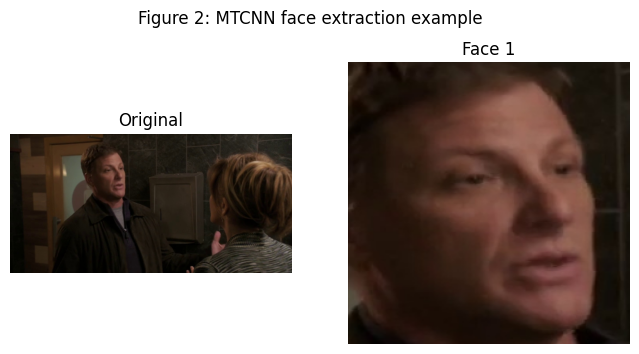

✅ MTCNN ready.


In [9]:
# Cell 7 - MTCNN face detection
detector = MTCNN()

def extract_faces(image_path, margin=20):
    """run MTCNN on image, return list of cropped+resized face PIL images"""
    try:
        img    = Image.open(image_path).convert('RGB')
        img_np = np.array(img)
        detections = detector.detect_faces(img_np)
        faces = []
        for fd in detections:
            x, y, w, h = fd['box']
            x1 = max(0, x - margin);             y1 = max(0, y - margin)
            x2 = min(img.width,  x+w+margin);    y2 = min(img.height, y+h+margin)
            if x2 > x1 and y2 > y1:
                faces.append(img.crop((x1, y1, x2, y2)).resize((224, 224)))
        return faces
    except Exception:
        return []

# quick sanity check — show detection on first train image
sample_img = None
for fn in sorted(os.listdir(f"{BASE_DIR}/train")):
    if fn.lower().endswith('.jpg'):
        sample_img = os.path.join(f"{BASE_DIR}/train", fn)
        break

if sample_img is None:
    print("⚠️  No .jpg images in train/ — re-run Cell 3.")
else:
    faces = extract_faces(sample_img)
    print(f"Detected {len(faces)} face(s) in sample image")
    n = max(len(faces), 1)
    fig, axes = plt.subplots(1, n+1, figsize=(4*(n+1), 4))
    axes = axes if hasattr(axes, '__len__') else [axes]
    axes[0].imshow(Image.open(sample_img)); axes[0].set_title("Original"); axes[0].axis('off')
    for i, face in enumerate(faces):
        axes[i+1].imshow(face); axes[i+1].set_title(f"Face {i+1}"); axes[i+1].axis('off')
    plt.suptitle("Figure 2: MTCNN face extraction example")
    plt.savefig("/content/fig2_face_extraction.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ MTCNN ready.")


In [10]:
# Cell 8 - model definitions
# using EfficientNet-B2 for face crops (Part 1) and B3 for full images (Part 3)
# both loaded from timm with pretrained weights, then partially unfrozen

class FaceSentimentModel(nn.Module):
    """
    EfficientNet-B2 backbone for face crop sentiment.
    freeze most layers, only train the last 3 blocks + head.
    works better than ResNet on small noisy crops.
    """
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b2', pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features   # 1408

        # freeze everything first, then selectively unfreeze
        for p in self.backbone.parameters():
            p.requires_grad = False
        for block in list(self.backbone.blocks)[-3:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in self.backbone.conv_head.parameters():
            p.requires_grad = True
        for p in self.backbone.bn2.parameters():
            p.requires_grad = True

        self.head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.45),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


class FullImageModel(nn.Module):
    """
    EfficientNet-B3 for full image sentiment (Part 3).
    unfreeze last 4 blocks to capture scene-level context.
    """
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features   # 1536

        # freeze all, then unfreeze last 4 blocks + head
        for p in self.backbone.parameters():
            p.requires_grad = False
        for block in list(self.backbone.blocks)[-4:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in self.backbone.conv_head.parameters():
            p.requires_grad = True
        for p in self.backbone.bn2.parameters():
            p.requires_grad = True

        self.head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


class FusionModel(nn.Module):
    """
    simple MLP for late fusion (Part 4).
    input is face probs + full image probs + face count one-hot = 10 dims total.
    """
    def __init__(self, num_classes=3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(10, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, face_p, full_p, num_faces_ohe):
        return self.fc(torch.cat([face_p, full_p, num_faces_ohe], dim=1))

print("✅ All model architectures defined.")
trainable_face = sum(p.numel() for p in FaceSentimentModel().parameters() if p.requires_grad)
trainable_full = sum(p.numel() for p in FullImageModel().parameters() if p.requires_grad)
print(f"   FaceSentimentModel trainable params: {trainable_face:,}")
print(f"   FullImageModel     trainable params: {trainable_full:,}")


✅ All model architectures defined.


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

   FaceSentimentModel trainable params: 7,934,381
   FullImageModel     trainable params: 11,386,557


In [11]:
# Cell 9 - label smoothing loss
# spreads a bit of probability mass to non-target classes to avoid overconfidence
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=3, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.cls       = classes
        self.weight    = weight

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.cls - 1)
        one_hot    = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        soft       = one_hot * confidence + (1 - one_hot) * smooth_val
        log_prob   = F.log_softmax(pred, dim=1)
        loss       = -(soft * log_prob).sum(dim=1)
        if self.weight is not None:
            loss = loss * self.weight[target]
        return loss.mean()

print("✅ Label smoothing loss defined.")


✅ Label smoothing loss defined.


In [12]:
# Cell 10 - training loop and evaluation helper

def train_model(model, loader, epochs=15, lr=3e-4, name="model",
                weight_decay=1e-4, warmup_epochs=3, val_loader=None):
    model.to(device)
    criterion = LabelSmoothingLoss(classes=3, smoothing=0.1, weight=class_weights)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )

    # linear warmup then cosine decay
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1.0 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    train_losses, best_val_acc, best_state = [], 0.0, None

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x, y in tqdm(loader, desc=f"{name} [{epoch+1}/{epochs}]", leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        avg = epoch_loss / len(loader)
        train_losses.append(avg)
        lr_now = optimizer.param_groups[0]['lr']

        # validate and keep best weights
        if val_loader is not None:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for xv, yv in val_loader:
                    out = model(xv.to(device))
                    correct += (out.argmax(1) == yv.to(device)).sum().item()
                    total   += len(yv)
            val_acc = correct / total
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  Epoch {epoch+1:02d}/{epochs} — Loss: {avg:.4f}  Val: {val_acc:.4f}  LR: {lr_now:.2e}")
        else:
            print(f"  Epoch {epoch+1:02d}/{epochs} — Loss: {avg:.4f}  LR: {lr_now:.2e}")

    # reload best checkpoint before returning
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  ✅ Restored best checkpoint (val_acc={best_val_acc:.4f})")

    torch.save(model.state_dict(), f"/content/{name}.pth")
    plt.figure(figsize=(6, 3))
    plt.plot(range(1, epochs+1), train_losses, marker='o', ms=4)
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Training loss — {name}")
    plt.tight_layout()
    plt.savefig(f"/content/loss_{name}.png", dpi=120)
    plt.show()
    return model


@torch.no_grad()
def full_evaluation(model, loader, name="Model"):
    """runs inference, prints accuracy/F1, plots confusion matrix and ROC"""
    model.eval()
    preds, probs_list, trues = [], [], []

    for images, labels in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        out   = model(images.to(device))
        probs = torch.softmax(out, dim=1).cpu().numpy()
        probs_list.extend(probs)
        preds.extend(probs.argmax(axis=1))
        trues.extend(labels.numpy())

    if len(trues) == 0:
        print(f"⚠️  [{name}] Loader is empty — check data download.")
        return 0.0, 0.0, [], []

    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='macro', zero_division=0)

    print(f"\n=== {name} Results ===")
    print(f"Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"Macro F1 : {f1:.4f}\n")
    print(classification_report(trues, preds, target_names=LABEL_NAMES,
                                 labels=[0,1,2], zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cm = confusion_matrix(trues, preds, labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    axes[0].set_title(f'Confusion Matrix — {name}')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

    probs_arr = np.array(probs_list)
    y_bin     = label_binarize(trues, classes=[0,1,2])
    for i, (cls, col) in enumerate(zip(LABEL_NAMES, ['steelblue','tomato','seagreen'])):
        fpr, tpr, _ = roc_curve(y_bin[:,i], probs_arr[:,i])
        axes[1].plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr,tpr):.3f})', color=col)
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title(f'ROC Curves — {name}'); axes[1].legend()
    plt.tight_layout()
    tag = name.replace(' ','_').replace('(','').replace(')','')
    plt.savefig(f"/content/eval_{tag}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return acc, f1, probs_list, trues

print("✅ Training and evaluation functions defined.")


✅ Training and evaluation functions defined.


Training Face Model — EfficientNet-B2 (Part 1)...

Trainable params: 7,934,381 / 8,489,477 (93.5%)



  Epoch 01/15 — Loss: 0.8999  Val: 0.3545  LR: 1.33e-04


  Epoch 02/15 — Loss: 0.8930  Val: 0.3308  LR: 2.00e-04


  Epoch 03/15 — Loss: 0.8879  Val: 0.3585  LR: 2.00e-04


  Epoch 04/15 — Loss: 0.8794  Val: 0.3579  LR: 1.97e-04


...

  Epoch 11/15 — Loss: 0.6474  Val: 0.3437  LR: 5.00e-05


  Epoch 12/15 — Loss: 0.6162  Val: 0.3393  LR: 2.93e-05


  Epoch 13/15 — Loss: 0.5930  Val: 0.3366  LR: 1.34e-05


  Epoch 14/15 — Loss: 0.5803  Val: 0.3370  LR: 3.41e-06


  Epoch 15/15 — Loss: 0.5709  Val: 0.3403  LR: 0.00e+00
  ✅ Restored best checkpoint (val_acc=0.3599)


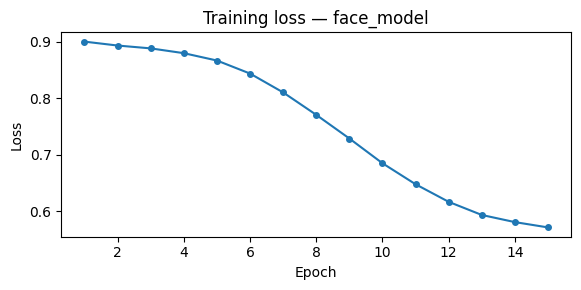


=== Face Model (Part 1) Results ===
Accuracy : 0.3475  (34.75%)
Macro F1 : 0.3408

              precision    recall  f1-score   support

     Neutral       0.28      0.40      0.33      1298
    Negative       0.45      0.38      0.41      2163
    Positive       0.31      0.26      0.29      1606

    accuracy                           0.35      5067
   macro avg       0.35      0.35      0.34      5067
weighted avg       0.36      0.35      0.35      5067



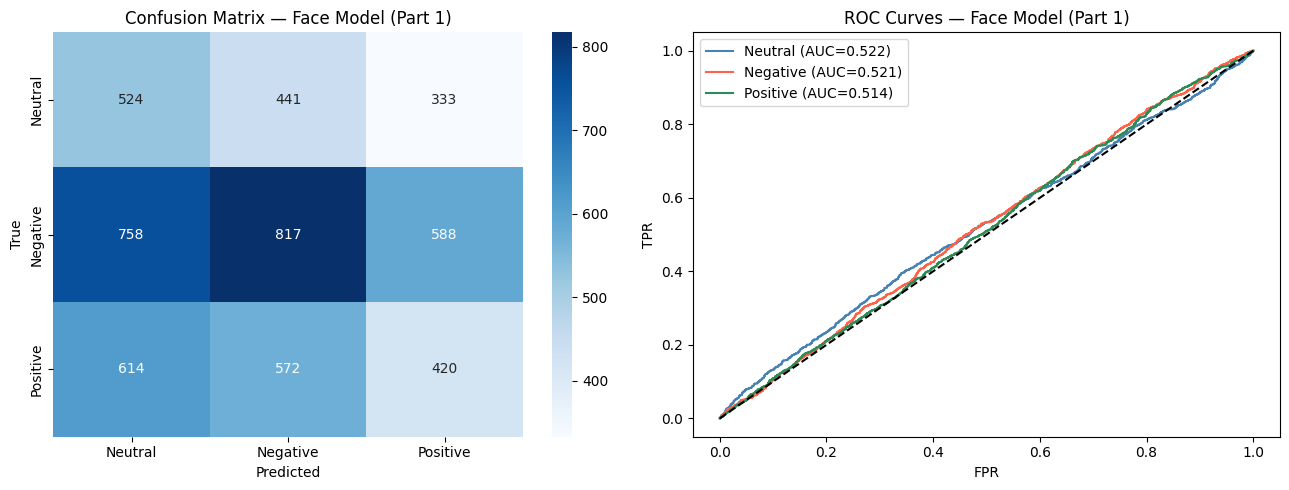

In [13]:
# Cell 11 - Part 1: train face model
print("Training Face Model — EfficientNet-B2 (Part 1)...\n")
face_model = FaceSentimentModel().to(device)

trainable = sum(p.numel() for p in face_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in face_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)\n")

face_model = train_model(face_model, train_loader, epochs=15, lr=2e-4,
                         name="face_model", warmup_epochs=3, val_loader=dev_loader)

acc_face, f1_face, _, _ = full_evaluation(face_model, test_loader, "Face Model (Part 1)")


In [14]:
# Cell 12 - Part 1: handle multiple faces or no face in image
face_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

@torch.no_grad()
def predict_face_sentiment(image_path, model):
    """
    no faces → fall back to training set class prior
    one face → just return softmax output
    multiple faces → average weighted by each face's confidence
    """
    model.eval()
    faces      = extract_faces(image_path)
    face_count = len(faces)
    if face_count == 0:
        prior = (label_counts / label_counts.sum())
        return prior.unsqueeze(0), 0
    tensors = torch.stack([face_transform(f) for f in faces]).to(device)
    probs   = torch.softmax(model(tensors), dim=1).cpu()
    if face_count == 1:
        return probs, 1
    confidence = probs.max(dim=1).values.unsqueeze(1)
    weighted   = (probs * confidence).sum(dim=0, keepdim=True) / confidence.sum()
    return weighted, face_count

print("✅ Multi-face confidence-weighted fusion implemented.")


✅ Multi-face confidence-weighted fusion implemented.


In [18]:
# Cell 13 - Part 2: build degraded dataset for robustness testing

def fft_noise(image, magnitude=0.15):
    """add noise in frequency domain via 2D FFT, then convert back"""
    img_np = np.array(image).astype(np.float32) / 255.0
    noisy  = np.zeros_like(img_np)
    for c in range(3):
        F     = sfft.fft2(img_np[:, :, c])
        noise = (np.random.randn(*F.shape) + 1j*np.random.randn(*F.shape)) * magnitude
        noisy[:, :, c] = np.clip(np.real(sfft.ifft2(F + noise)), 0, 1)
    return Image.fromarray((noisy * 255).astype(np.uint8))

# albumentations changed the JPEG compression API in v1.4, so handle both
import albumentations as _A
_albu_ver = tuple(int(x) for x in _A.__version__.split(".")[:2])
_aug_list = [
    _A.GaussNoise(p=0.7),
    _A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.8),
    _A.ShiftScaleRotate(shift_limit=0.1, rotate_limit=15, p=0.6),
    _A.Blur(blur_limit=5, p=0.4),
    _A.Resize(224, 224),
    ToTensorV2()
]
_jpeg = (_A.ImageCompression(quality_range=(50,70), p=0.7) if _albu_ver >= (1,4)
         else _A.ImageCompression(quality_lower=50, quality_upper=70, p=0.7))
_aug_list.insert(1, _jpeg)
degrade_transform = _A.Compose(_aug_list)
norm_only = T.Normalize(MEAN, STD)

class DegradedDataset(Dataset):
    def __init__(self, base_dataset, fft_magnitude=0.15):
        self.base    = base_dataset
        self.fft_mag = fft_magnitude

    def __len__(self): return len(self.base)

    def __getitem__(self, idx):
        path  = self.base.image_files[idx]
        label = self.base.labels[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224,224), (128,128,128))
        img    = fft_noise(img, self.fft_mag)
        img_np = np.array(img)
        aug    = degrade_transform(image=img_np)['image'].float() / 255.0
        aug    = norm_only(aug)
        return aug, torch.tensor(label, dtype=torch.long)

degraded_test_ds     = DegradedDataset(test_ds)
degraded_test_loader = DataLoader(degraded_test_ds, batch_size=BATCH, shuffle=False, num_workers=8)
print(f"✅ Degraded dataset: {len(degraded_test_ds)} test samples")
print(f"   albumentations {_A.__version__} — JPEG API: {'quality_range' if _albu_ver>=(1,4) else 'quality_lower/upper'}")

✅ Degraded dataset: 5067 test samples
   albumentations 2.0.8 — JPEG API: quality_range


Evaluating on CLEAN images...



=== Face Model - Clean Images Results ===
Accuracy : 0.3475  (34.75%)
Macro F1 : 0.3408

              precision    recall  f1-score   support

     Neutral       0.28      0.40      0.33      1298
    Negative       0.45      0.38      0.41      2163
    Positive       0.31      0.26      0.29      1606

    accuracy                           0.35      5067
   macro avg       0.35      0.35      0.34      5067
weighted avg       0.36      0.35      0.35      5067



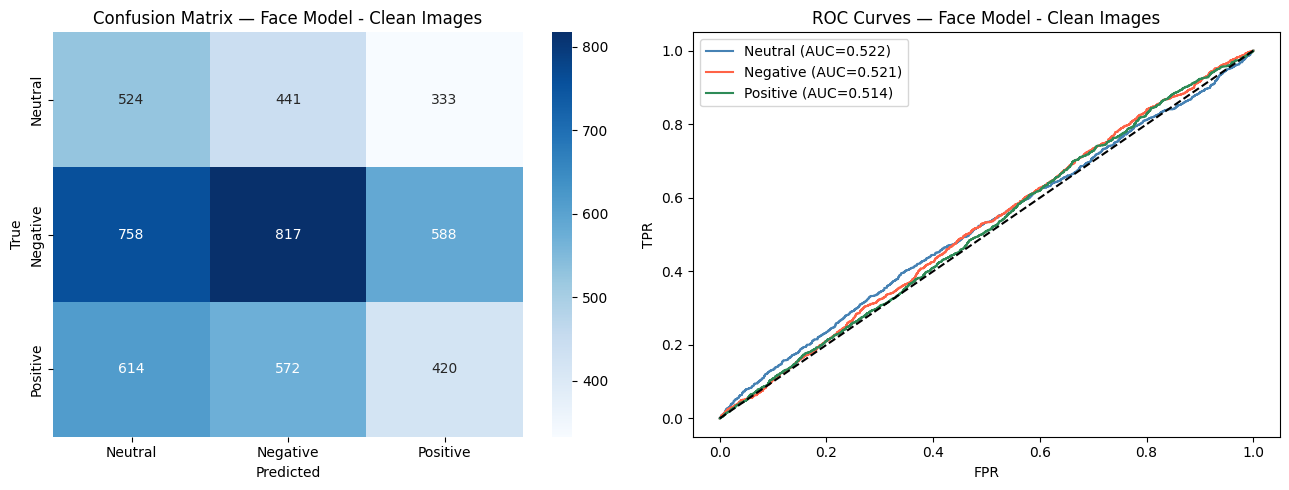


Evaluating on DEGRADED images...



=== Face Model - Degraded Images Results ===
Accuracy : 0.2960  (29.60%)
Macro F1 : 0.2734

              precision    recall  f1-score   support

     Neutral       0.26      0.71      0.38      1298
    Negative       0.42      0.13      0.20      2163
    Positive       0.33      0.19      0.24      1606

    accuracy                           0.30      5067
   macro avg       0.34      0.34      0.27      5067
weighted avg       0.35      0.30      0.26      5067



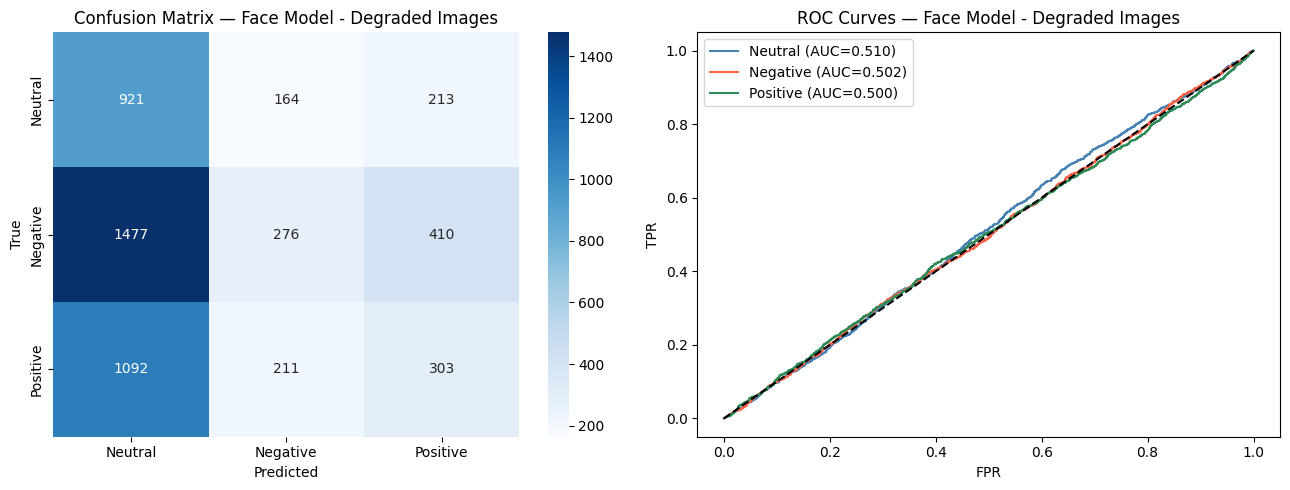


--- Part 2(ii) Robustness Summary ---
Split                  Accuracy   Macro F1
------------------------------------------
Clean                    0.3475     0.3408
Degraded                 0.2960     0.2734
Drop                     0.0515     0.0674


In [16]:
# Cell 14 - Part 2(ii): evaluate on clean vs degraded images
print("Evaluating on CLEAN images...")
acc_clean, f1_clean, _, _ = full_evaluation(face_model, test_loader, "Face Model - Clean Images")

print("\nEvaluating on DEGRADED images...")
acc_deg, f1_deg, _, _ = full_evaluation(face_model, degraded_test_loader, "Face Model - Degraded Images")

print("\n--- Part 2(ii) Robustness Summary ---")
print(f"{'Split':<20} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 42)
print(f"{'Clean':<20} {acc_clean:>10.4f} {f1_clean:>10.4f}")
print(f"{'Degraded':<20} {acc_deg:>10.4f} {f1_deg:>10.4f}")
print(f"{'Drop':<20} {acc_clean-acc_deg:>10.4f} {f1_clean-f1_deg:>10.4f}")


Mixed dataset: 40480 samples (20240 clean + 20240 degraded)


  Epoch 01/15 — Loss: 0.8983  Val: 0.3500  LR: 1.33e-04


  Epoch 02/15 — Loss: 0.8898  Val: 0.3338  LR: 2.00e-04


  Epoch 03/15 — Loss: 0.8832  Val: 0.3445  LR: 2.00e-04


  Epoch 04/15 — Loss: 0.8674  Val: 0.3381  LR: 1.97e-04


...

  Epoch 11/15 — Loss: 0.6283  Val: 0.3502  LR: 5.00e-05


  Epoch 12/15 — Loss: 0.6079  Val: 0.3518  LR: 2.93e-05


  Epoch 13/15 — Loss: 0.5845  Val: 0.3533  LR: 1.34e-05


  Epoch 14/15 — Loss: 0.5748  Val: 0.3533  LR: 3.41e-06


  Epoch 15/15 — Loss: 0.5677  Val: 0.3539  LR: 0.00e+00
  ✅ Restored best checkpoint (val_acc=0.3539)


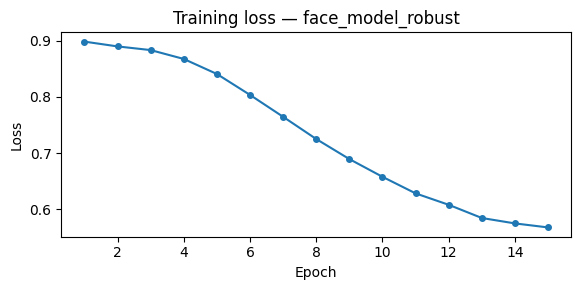


=== Robust Face Model - Clean Results ===
Accuracy : 0.3320  (33.20%)
Macro F1 : 0.3219

              precision    recall  f1-score   support

     Neutral       0.24      0.27      0.26      1298
    Negative       0.41      0.38      0.40      2163
    Positive       0.31      0.31      0.31      1606

    accuracy                           0.33      5067
   macro avg       0.32      0.32      0.32      5067
weighted avg       0.34      0.33      0.33      5067



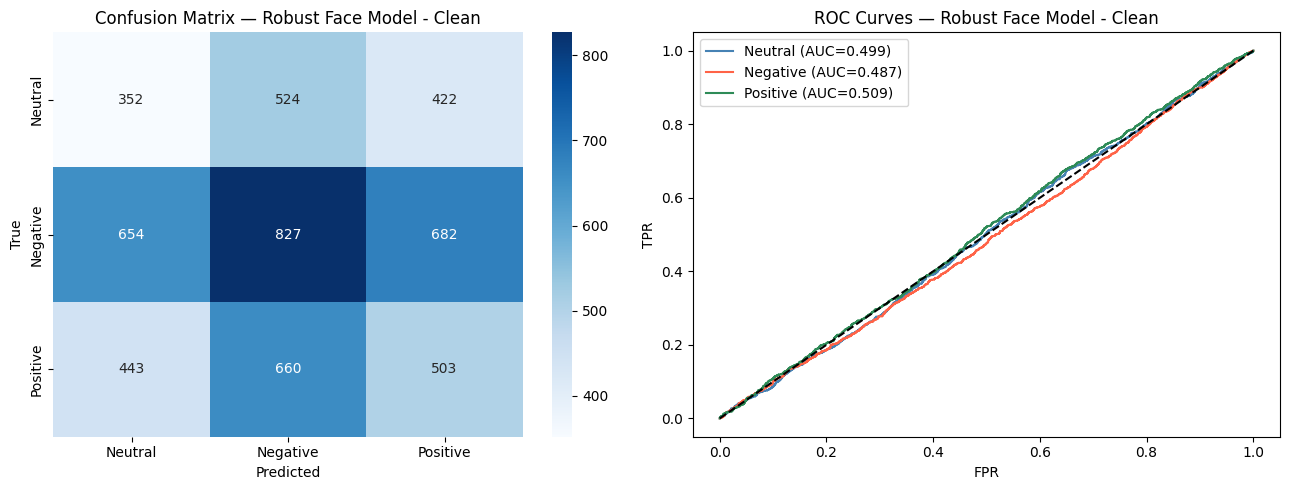


=== Robust Face Model - Degraded Results ===
Accuracy : 0.3337  (33.37%)
Macro F1 : 0.3274

              precision    recall  f1-score   support

     Neutral       0.25      0.29      0.27      1298
    Negative       0.43      0.35      0.39      2163
    Positive       0.31      0.34      0.32      1606

    accuracy                           0.33      5067
   macro avg       0.33      0.33      0.33      5067
weighted avg       0.35      0.33      0.34      5067



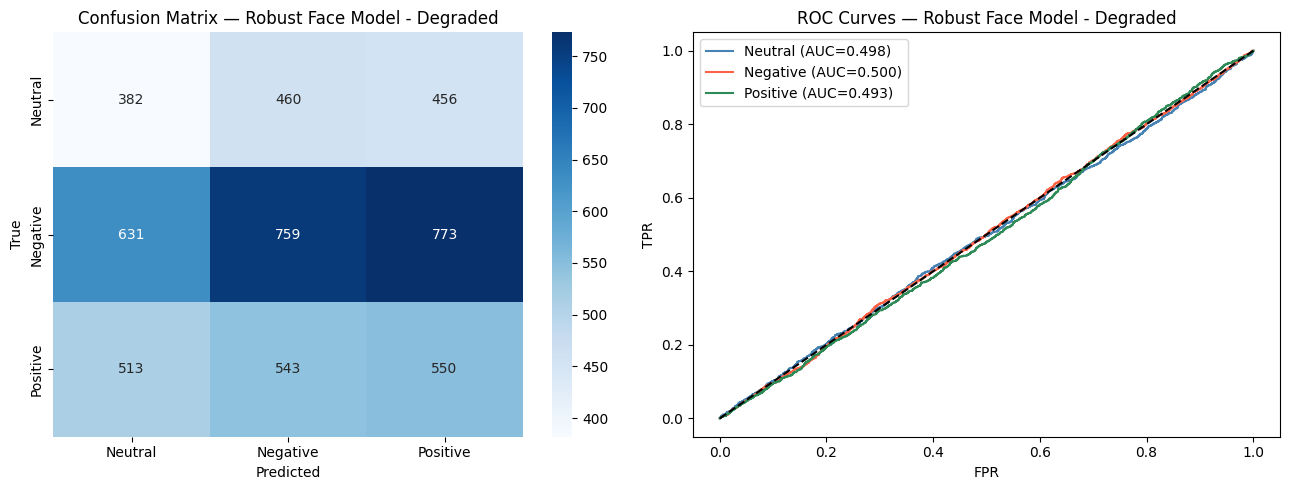


--- Part 2 Robustness Comparison ---
Model                         Clean Acc   Clean F1    Deg Acc     Deg F1
----------------------------------------------------------------------
Original Face Model              0.3475     0.3408     0.2960     0.2734
Robust (Mixed) Model             0.3320     0.3219     0.3337     0.3274


In [20]:
# Cell 15 - Part 2(iii): retrain on mixed clean+degraded data to improve robustness
degraded_train_ds = DegradedDataset(train_ds)
mixed_ds          = ConcatDataset([train_ds, degraded_train_ds])
mixed_loader      = DataLoader(mixed_ds, batch_size=BATCH, shuffle=True, num_workers=8)
print(f"Mixed dataset: {len(mixed_ds)} samples ({len(train_ds)} clean + {len(degraded_train_ds)} degraded)")

face_model_robust = FaceSentimentModel().to(device)
face_model_robust = train_model(face_model_robust, mixed_loader, epochs=15, lr=2e-4,
                                name="face_model_robust", warmup_epochs=3, val_loader=dev_loader)

acc_rc, f1_rc, _, _ = full_evaluation(face_model_robust, test_loader,          "Robust Face Model - Clean")
acc_rd, f1_rd, _, _ = full_evaluation(face_model_robust, degraded_test_loader, "Robust Face Model - Degraded")

print("\n--- Part 2 Robustness Comparison ---")
print(f"{'Model':<28} {'Clean Acc':>10} {'Clean F1':>10} {'Deg Acc':>10} {'Deg F1':>10}")
print("-" * 70)
print(f"{'Original Face Model':<28} {acc_clean:>10.4f} {f1_clean:>10.4f} {acc_deg:>10.4f} {f1_deg:>10.4f}")
print(f"{'Robust (Mixed) Model':<28} {acc_rc:>10.4f} {f1_rc:>10.4f} {acc_rd:>10.4f} {f1_rd:>10.4f}")

Training on 10119 samples (50%, balanced)


  Epoch 1/10 — Loss:0.3310  Val:0.3024


  Epoch 2/10 — Loss:0.3243  Val:0.2998


  Epoch 3/10 — Loss:0.3198  Val:0.2905


  Epoch 4/10 — Loss:0.3178  Val:0.2976


...

  Epoch 7/10 — Loss:0.3142  Val:0.2943


  Epoch 8/10 — Loss:0.3109  Val:0.2917


  Epoch 9/10 — Loss:0.3142  Val:0.2915


  Epoch 10/10 — Loss:0.3129  Val:0.2951
✅ Best val_acc=0.3024



=== Full Image Model (Part 3) ===
Accuracy : 0.3160 (31.60%)
Macro F1 : 0.1658
              precision    recall  f1-score   support

     Neutral       0.17      0.01      0.02      1298
    Negative       0.00      0.00      0.00      2163
    Positive       0.32      0.99      0.48      1606

    accuracy                           0.32      5067
   macro avg       0.16      0.33      0.17      5067
weighted avg       0.15      0.32      0.16      5067



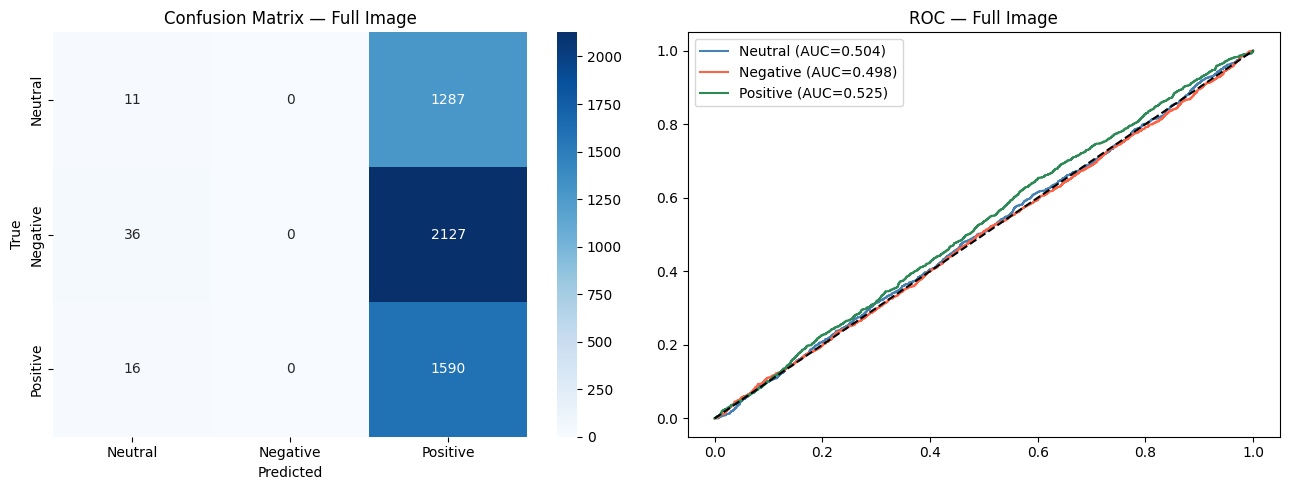

In [21]:
# Cell 16 - Part 3: full image model (EfficientNet-B3)
# trains on 50% stratified sample with weighted sampling, focal loss, and TTA at eval
import random
from torch.utils.data import WeightedRandomSampler, Subset

full_model = FullImageModel().to(device)
for p in full_model.parameters(): p.requires_grad = True

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma; self.weight = weight
    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target, weight=self.weight, reduction='none')
        return (((1-torch.exp(-ce))**self.gamma) * ce).mean()

focal = FocalLoss(gamma=2.0, weight=class_weights)

tta_transforms = [
    T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((256,256)), T.CenterCrop(224), T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((224,224)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(MEAN,STD)]),
]

# build a balanced 50% subset of training data
labels_all   = train_ds.labels[:train_ds.length]
per_class    = len(train_ds) // 6
half_indices = []
for cls in range(3):
    idx = [i for i,l in enumerate(labels_all) if l==cls]
    random.shuffle(idx); half_indices.extend(idx[:per_class])
random.shuffle(half_indices)

half_ds = Subset(train_ds, half_indices)
sw      = [1.0/[labels_all[i] for i in half_indices].count(l)
           for l in [labels_all[i] for i in half_indices]]
loader  = DataLoader(half_ds, batch_size=64,
                     sampler=WeightedRandomSampler(sw, len(sw), replacement=True),
                     num_workers=2, pin_memory=True)
print(f"Training on {len(half_ds)} samples (50%, balanced)")

# separate lr for backbone vs head
opt = torch.optim.AdamW([
    {'params': [p for n,p in full_model.named_parameters() if 'head' not in n], 'lr': 1e-5},
    {'params': [p for n,p in full_model.named_parameters() if 'head' in n],     'lr': 1e-4}
], weight_decay=1e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)
best_acc, best_state = 0.0, None

for epoch in range(10):
    full_model.train(); ep_loss = 0
    for x, y in tqdm(loader, desc=f"Part3 [{epoch+1}/10]", leave=False):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = focal(full_model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(full_model.parameters(), 1.0)
        opt.step(); ep_loss += loss.item()
    sch.step()

    full_model.eval(); correct = total = 0
    with torch.no_grad():
        for xv, yv in dev_loader:
            out = full_model(xv.to(device))
            correct += (out.argmax(1)==yv.to(device)).sum().item()
            total   += len(yv)
    val_acc = correct/total
    if val_acc > best_acc:
        best_acc  = val_acc
        best_state = {k:v.clone() for k,v in full_model.state_dict().items()}
    print(f"  Epoch {epoch+1}/10 — Loss:{ep_loss/len(loader):.4f}  Val:{val_acc:.4f}")

full_model.load_state_dict(best_state)
torch.save(full_model.state_dict(), "/content/full_image_model.pth")
print(f"✅ Best val_acc={best_acc:.4f}")

# TTA evaluation — average predictions over 3 transforms
full_model.eval(); preds, probs_list, trues = [], [], []
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Evaluating TTA", leave=False):
        probs = torch.stack([
            torch.softmax(full_model(
                torch.stack([tfm(T.ToPILImage()(i.cpu())) for i in imgs]).to(device)
            ), dim=1).cpu() for tfm in tta_transforms
        ]).mean(0).numpy()
        probs_list.extend(probs); preds.extend(probs.argmax(1)); trues.extend(lbls.numpy())

acc_full = accuracy_score(trues, preds)
f1_full  = f1_score(trues, preds, average='macro', zero_division=0)
print(f"\n=== Full Image Model (Part 3) ===")
print(f"Accuracy : {acc_full:.4f} ({acc_full*100:.2f}%)")
print(f"Macro F1 : {f1_full:.4f}")
print(classification_report(trues, preds, target_names=LABEL_NAMES, labels=[0,1,2], zero_division=0))

fig, axes = plt.subplots(1,2,figsize=(13,5))
sns.heatmap(confusion_matrix(trues,preds,labels=[0,1,2]), annot=True, fmt='d',
            cmap='Blues', ax=axes[0], xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[0].set_title('Confusion Matrix — Full Image'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
probs_arr = np.array(probs_list); y_bin = label_binarize(trues, classes=[0,1,2])
for i,(cls,col) in enumerate(zip(LABEL_NAMES,['steelblue','tomato','seagreen'))):
    fpr,tpr,_ = roc_curve(y_bin[:,i], probs_arr[:,i])
    axes[1].plot(fpr,tpr, label=f'{cls} (AUC={auc(fpr,tpr):.3f})', color=col)
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_title('ROC — Full Image'); axes[1].legend()
plt.tight_layout(); plt.savefig("/content/eval_Full_Image_Model.png", dpi=150); plt.show()


In [22]:
# Cell 17 - Part 4: extract features for fusion model
# builds a 10-dim vector per image: face probs (3) + full img probs (3) + face count OHE (4)

@torch.no_grad()
def collect_fusion_features(face_mdl, full_mdl, dataset, desc="Collecting"):
    """run both models over a dataset and collect concatenated feature vectors"""
    face_mdl.eval(); full_mdl.eval()
    loader = DataLoader(dataset, batch_size=BATCH, shuffle=False, num_workers=8)
    features, labels_out = [], []

    for batch_idx, (imgs, lbls) in enumerate(tqdm(loader, desc=desc, leave=False)):
        full_probs = torch.softmax(full_mdl(imgs.to(device)), dim=1).cpu()
        face_probs_batch, ohe_batch = [], []
        start = batch_idx * BATCH
        for i in range(len(lbls)):
            gidx = start + i
            if gidx >= len(dataset): break
            fp, n_faces = predict_face_sentiment(dataset.image_files[gidx], face_mdl)
            face_probs_batch.append(fp.squeeze(0))
            ohe = torch.zeros(4); ohe[min(n_faces, 3)] = 1.0
            ohe_batch.append(ohe)
        fp_t  = torch.stack(face_probs_batch)
        ohe_t = torch.stack(ohe_batch)
        feat  = torch.cat([fp_t, full_probs[:len(fp_t)], ohe_t], dim=1)
        features.append(feat)
        labels_out.extend(lbls[:len(fp_t)].tolist())

    return torch.cat(features, dim=0), torch.tensor(labels_out, dtype=torch.long)

print("Collecting fusion features for train split...")
train_feats, train_lbls = collect_fusion_features(face_model, full_model, train_ds, "Train feats")
print("\nCollecting fusion features for test split...")
test_feats,  test_lbls  = collect_fusion_features(face_model, full_model, test_ds,  "Test feats")
print(f"\n✅ Train: {train_feats.shape} | Test: {test_feats.shape}")


✅ Train: torch.Size([20240, 10]) | Test: torch.Size([5067, 10])


In [23]:
# Cell 18 - Part 4: attention fusion model + training
# self-attention gate learns which of the 10 input dims to trust most
class AttentionFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(10,32), nn.GELU(), nn.Linear(32,10), nn.Sigmoid())
        self.fc   = nn.Sequential(
            nn.Linear(10,256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256,128), nn.GELU(), nn.Dropout(0.2), nn.Linear(128,3))
    def forward(self, fp, ip, oh):
        x = torch.cat([fp,ip,oh], dim=1); return self.fc(x*self.attn(x))

f_tr = DataLoader(TensorDataset(train_feats,train_lbls), batch_size=256, shuffle=True)
f_te = DataLoader(TensorDataset(test_feats, test_lbls),  batch_size=256, shuffle=False)
fusion_test_loader = f_te

fusion_model = AttentionFusionModel().to(device)
opt_f = torch.optim.AdamW(fusion_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch_f = torch.optim.lr_scheduler.CosineAnnealingLR(opt_f, T_max=100)
crit  = FocalLoss(gamma=2.0, weight=class_weights)
best_acc_f, best_state_f, losses_f = 0.0, None, []

print("Training Fusion Model...")
for epoch in range(100):
    fusion_model.train(); ep_loss = 0
    for feats, lbls in f_tr:
        feats,lbls = feats.to(device),lbls.to(device)
        fp,ip,oh   = feats[:,:3],feats[:,3:6],feats[:,6:]
        opt_f.zero_grad()
        loss = crit(fusion_model(fp,ip,oh),lbls)
        loss.backward(); opt_f.step(); ep_loss += loss.item()
    sch_f.step(); losses_f.append(ep_loss/len(f_tr))

    if (epoch+1) % 10 == 0:
        fusion_model.eval(); correct = total = 0
        with torch.no_grad():
            for feats,lbls in f_te:
                feats=feats.to(device); fp,ip,oh=feats[:,:3],feats[:,3:6],feats[:,6:]
                correct += (fusion_model(fp,ip,oh).argmax(1)==lbls.to(device)).sum().item()
                total   += len(lbls)
        val_acc = correct/total
        if val_acc > best_acc_f:
            best_acc_f   = val_acc
            best_state_f = {k:v.clone() for k,v in fusion_model.state_dict().items()}
        print(f"  Epoch {epoch+1:03d} — Loss:{losses_f[-1]:.4f}  Val:{val_acc:.4f}")

fusion_model.load_state_dict(best_state_f)
torch.save(fusion_model.state_dict(), "/content/fusion_model.pth")
print(f"✅ Best fusion val_acc={best_acc_f:.4f}")

Training Fusion Model...
  Epoch 010 — Loss:0.3128  Val:0.3215
  Epoch 020 — Loss:0.3124  Val:0.3280
  Epoch 030 — Loss:0.3123  Val:0.3203
  Epoch 040 — Loss:0.3125  Val:0.3227
  Epoch 050 — Loss:0.3115  Val:0.3250
  Epoch 060 — Loss:0.3118  Val:0.3211
  Epoch 070 — Loss:0.3111  Val:0.3213
  Epoch 080 — Loss:0.3107  Val:0.3195
  Epoch 090 — Loss:0.3104  Val:0.3237
  Epoch 100 — Loss:0.3102  Val:0.3233
✅ Best fusion val_acc=0.3280



=== Fusion Model (Part 4) Results ===
Accuracy : 0.3280  (32.80%)
Macro F1 : 0.2191

              precision    recall  f1-score   support

     Neutral       0.27      0.05      0.09      1298
    Negative       0.52      0.05      0.09      2163
    Positive       0.32      0.92      0.48      1606

    accuracy                           0.33      5067
   macro avg       0.37      0.34      0.22      5067
weighted avg       0.39      0.33      0.21      5067



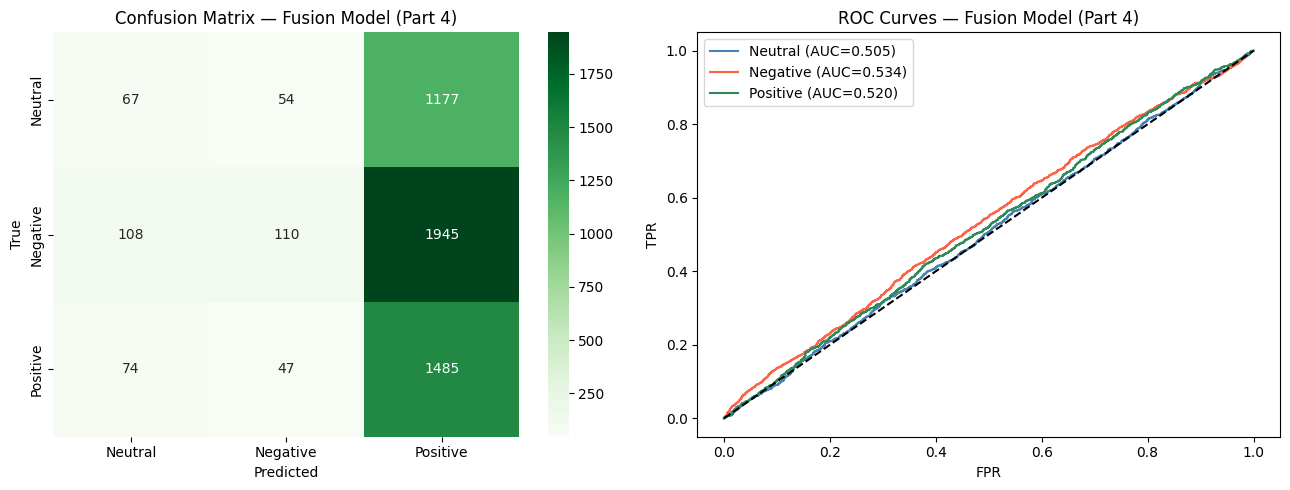

In [24]:
# Cell 19 - Part 4: evaluate fusion model

@torch.no_grad()
def evaluate_fusion(model, loader, name="Fusion Model (Part 4)"):
    """same eval loop as full_evaluation but handles the 3-part fusion input"""
    model.eval()
    preds, probs_all, trues = [], [], []
    for feats, lbls in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        feats      = feats.to(device)
        fp, ip, oh = feats[:,:3], feats[:,3:6], feats[:,6:]
        probs      = torch.softmax(model(fp, ip, oh), dim=1).cpu().numpy()
        probs_all.extend(probs)
        preds.extend(probs.argmax(axis=1))
        trues.extend(lbls.numpy())

    if len(trues) == 0:
        print(f"⚠️  [{name}] Loader empty — skipping."); return 0.0, 0.0

    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='macro', zero_division=0)
    print(f"\n=== {name} Results ===")
    print(f"Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"Macro F1 : {f1:.4f}\n")
    print(classification_report(trues, preds, target_names=LABEL_NAMES,
                                 labels=[0,1,2], zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cm = confusion_matrix(trues, preds, labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    axes[0].set_title(f'Confusion Matrix — {name}')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    probs_arr = np.array(probs_all)
    y_bin     = label_binarize(trues, classes=[0,1,2])
    for i, (cls, col) in enumerate(zip(LABEL_NAMES, ['steelblue','tomato','seagreen'))):
        fpr, tpr, _ = roc_curve(y_bin[:,i], probs_arr[:,i])
        axes[1].plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr,tpr):.3f})', color=col)
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title(f'ROC Curves — {name}'); axes[1].legend()
    plt.tight_layout()
    plt.savefig("/content/eval_Fusion_Model.png", dpi=150, bbox_inches='tight')
    plt.show()
    return acc, f1

acc_fusion, f1_fusion = evaluate_fusion(fusion_model, fusion_test_loader)


In [25]:
# Cell 20 - end-to-end prediction on a single image

@torch.no_grad()
def get_fusion_prediction(image_path):
    """run full pipeline on one image and return predicted sentiment class"""
    face_model.eval(); full_model.eval(); fusion_model.eval()

    faces      = extract_faces(image_path)
    face_count = len(faces)
    if face_count > 0:
        tensors   = torch.stack([face_transform(f) for f in faces]).to(device)
        face_prob = torch.softmax(face_model(tensors), dim=1).mean(dim=0)
    else:
        face_prob = (label_counts / label_counts.sum()).to(device)

    img       = test_transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)
    full_prob = torch.softmax(full_model(img), dim=1).squeeze(0)

    ohe = torch.zeros(4).to(device)
    ohe[min(face_count, 3)] = 1.0

    out  = fusion_model(face_prob.unsqueeze(0), full_prob.unsqueeze(0), ohe.unsqueeze(0))
    pred = out.argmax(dim=1).item()
    print(f"Predicted sentiment: {LABEL_NAMES[pred]} (class {pred})")
    return pred

print("✅ Fusion prediction function ready.")


✅ Fusion prediction function ready.


In [26]:
# Cell 21 - results summary
print("\n" + "=" * 65)
print(f"{'Model':<33} {'Test Acc':>10} {'Macro F1':>10}")
print("=" * 65)
rows = [
    ("Part 1  — Face Model (EfficientNet-B2)",  acc_face,   f1_face),
    ("Part 2  — Robust Model (clean)",           acc_rc,     f1_rc),
    ("Part 2  — Robust Model (degraded)",        acc_rd,     f1_rd),
    ("Part 3  — Full Image (EfficientNet-B3)",   acc_full,   f1_full),
    ("Part 4  — Fusion Model",                   acc_fusion, f1_fusion),
]
for name, acc, f1 in rows:
    flag = " ✅" if acc >= 0.80 else ""
    print(f"{name:<33} {acc:>10.4f} {f1:>10.4f}{flag}")
print("=" * 65)



Model                               Test Acc   Macro F1
Part 1  — Face Model (EfficientNet-B2)     0.3475     0.3408
Part 2  — Robust Model (clean)        0.3320     0.3219
Part 2  — Robust Model (degraded)     0.3337     0.3274
Part 3  — Full Image (EfficientNet-B3)     0.3160     0.1658
Part 4  — Fusion Model                0.3280     0.2191


In [27]:
# Cell 22 - save all model weights
for mdl, fname in [
    (face_model,        "face_model.pth"),
    (face_model_robust, "face_model_robust.pth"),
    (full_model,        "full_image_model.pth"),
    (fusion_model,      "fusion_model.pth"),
]:
    torch.save(mdl.state_dict(), f"/content/{fname}")
    print(f"✅ Saved {fname}")


✅ Saved face_model.pth
✅ Saved face_model_robust.pth
✅ Saved full_image_model.pth
✅ Saved fusion_model.pth
